In [5]:
# !pip install langgraph langsmith

In [8]:
# !pip install langchain langchain_groq langchain_community

In [14]:
from google.colab import userdata
groq_api_key=userdata.get('groq_api_key')
# print(groq_api_key)
langsmith = userdata.get('langsmith_api_key')
# print(langsmith)

In [15]:
# Groq's Language Processing Unit (LPU) system aims to deliver lightning-fast inference speeds for Large Language Models (LLMs), surpassing other inference APIs such as those provided by OpenAI and Azure.

# LangSmith is a platform developed by LangChain for building, testing, debugging, evaluating, and monitoring LLM applications,
# offering tools for tracing, datasets, and prompt management to streamline the entire LLM application lifecycle.

##### Groq's Language Processing Unit (LPU) system aims to deliver lightning-fast inference speeds for Large Language Models (LLMs), surpassing other inference APIs such as those provided by OpenAI and Azure.

##### LangSmith is a platform developed by LangChain for building, testing, debugging, evaluating, and monitoring LLM applications, offering tools for tracing, datasets, and prompt management to streamline the entire LLM application lifecycle.

In [19]:
import os
os.environ['LANGCHAIN_API_KEY'] = langsmith
os.environ['LANGCHAIN_TRACING_V2'] = "true"
os.environ['LANGCHAIN_PROJECT'] = "Build AI Agent #1"

In [17]:
from langchain_groq import ChatGroq

In [18]:
llm=ChatGroq(groq_api_key = groq_api_key, model_name="Gemma2-9b-It")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x790845885810>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x790845556250>, model_name='Gemma2-9b-It', model_kwargs={}, groq_api_key=SecretStr('**********'))

## Start Building ChatBot Using LangGrpah

In [21]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import Graph, START, END
from langgraph.graph.message import add_messages

In [27]:
class State(TypedDict):
  #Messages have the type "list". The "add_messages" function
  # in the annotation defines how this state key should be updated
  # (in this case, it appends messages to the list, rather than overwriting them)

  messages: Annotated[list, add_messages]

graph_builder = Graph()
initial_state = State(messages=[])

In [29]:
def chatbot(state: State):

  return {"messages":llm.invoke(state['messages'])}

In [30]:
graph_builder.add_node("chatbot", chatbot)

Connect ChatBot to the graph Builder

In [31]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [32]:
graph = graph_builder.compile()

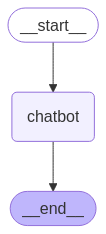

In [33]:
from IPython.display import Image,display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
  pass

In [ ]:
while True:
  user_input=input("User: ")
  if user_input.lower() in ["quit","q"]:
    print("Good Bye")
    break
  for event in graph.stream({'messages':("user",user_input)}):
    print(event.values())
    for value in event.values():
      print(value['messages'])
      print("Assistant:",value['messages'].content)

User: hello
dict_values([{'messages': AIMessage(content='Hello! 👋 \n\nHow can I help you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 21, 'total_tokens': 36, 'completion_time': 0.027272727, 'prompt_time': 0.002138086, 'queue_time': 0.017010472, 'total_time': 0.029410813}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run-ce6a9b4d-2621-4cac-891f-3800dcafcaea-0', usage_metadata={'input_tokens': 21, 'output_tokens': 15, 'total_tokens': 36})}])
content='Hello! 👋 \n\nHow can I help you today? 😊' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 21, 'total_tokens': 36, 'completion_time': 0.027272727, 'prompt_time': 0.002138086, 'queue_time': 0.017010472, 'total_time': 0.029410813}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None} id='run-ce6a9b4d-26